In [192]:
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

In [193]:
root_path = "/Users/asandeistefan/Downloads/emoji_cnt_dataset"

sample_img_path = f"{root_path}/train/train_542.png"

# Data

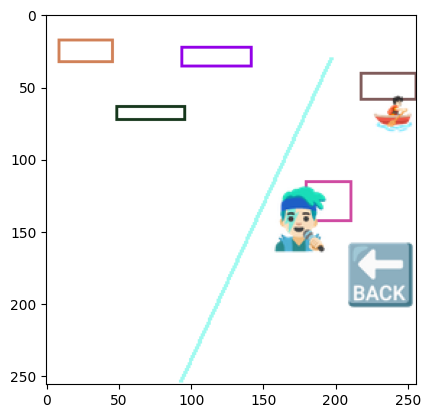

In [194]:
img = Image.open(sample_img_path).convert("RGB")
img = np.array(img)
plt.imshow(img)

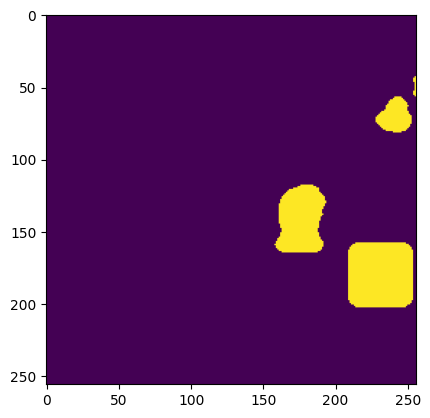

In [195]:
def get_mask(img: np.array) -> np.array:
    grayscale = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blur = cv2.medianBlur(grayscale, 11)

    _, threshold = cv2.threshold(blur, 254.9, 256, cv2.THRESH_BINARY_INV)
    return threshold  # .shape = (256, 256)

plt.imshow(get_mask(img))

In [ ]:
def count_components(mask: np.array, min_area: int = 195) -> int:
    num_labels, _, stats, _ = cv2.connectedComponentsWithStats(
        mask, connectivity=8
    )

    # filter components by area (exclude background label 0)
    valid_components = sum(
        1 for i in range(1, num_labels) if stats[i, cv2.CC_STAT_AREA] >= min_area
    )

    return valid_components

In [ ]:
mask = get_mask(img)
emoji_count = count_components(mask)
print(f"Emojis detected for sample image: {emoji_count}")

Emojis detected: 3


# Submission

In [198]:
test_csv_path = f"{root_path}/test.csv"
test_df = pd.read_csv(test_csv_path)

In [199]:
predictions = []

for idx, row in tqdm(
    test_df.iterrows(), total=len(test_df), desc="Processing test set"
):
    sample_id = row["SampleID"]
    img_path = f"{root_path}/{row['Path'][len('emoji_dataset'):]}"

    img = Image.open(img_path).convert("RGB")
    img = np.array(img)

    mask = get_mask(img)
    count = count_components(mask)

    predictions.append({"SampleID": sample_id, "PredictedLabel": count})

Processing test set: 100%|██████████| 500/500 [00:03<00:00, 148.50it/s]


In [200]:
submission_df = pd.DataFrame(predictions)
submission_path = f"{root_path}/submission.csv"
submission_df.to_csv(submission_path, index=False)
print(f"Submission saved to {submission_path}")
print(submission_df.head())

Submission saved to /Users/asandeistefan/Downloads/emoji_cnt_dataset/submission.csv
    SampleID  PredictedLabel
0  test_1500               4
1  test_1501               5
2  test_1502               1
3  test_1503               4
4  test_1504               2
